### This notebook is for starting to analyse correlations between the MIDAS (historical Met Office) data and the PV_Live data.
Steps:
1. Replot a GSP from the bottom of 03 and identify nearby met office instruments (that are available at the time)
2. Pull PV_Live data from that day (already done in 03 notebook)
3. Pull MIDAS data from that day
4. Do a simple correl with closest instrument
    - should probably control for capacity, perhaps by dividing output by nominal capacity (given by PV_Live)
5. Try more advanced models with multiple instruments, based explicitly or implicitly on proximity

In [2]:
# from 03 notebook:

from pathlib import Path
import time

import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd
import requests

API_BASE_URL = "https://api.pvlive.uk/pvlive/api/v4"
CAPACITY_FIELD = "capacity_mwp"
# CAPACITY_FIELD = "installedcapacity_mwp"

REFERENCE_DATA_PATH = Path("../data/outputs/reference_data")
GSP_PATH = REFERENCE_DATA_PATH / "gsp_regions_with_colour_and_ghi_coverage.geojson"
OUTPUT_GEOJSON = REFERENCE_DATA_PATH / "gsp_regions_with_pvlive_capacity.geojson"
OUTPUT_CSV = REFERENCE_DATA_PATH / "gsp_regions_with_pvlive_capacity.csv"

# gsp_regions = gpd.read_file(GSP_PATH) # this uses the colour and GHI coverage geojson... i don't think i want to use this for now
gsp_regions = gpd.read_file(OUTPUT_GEOJSON) # this uses pvlive capacity

print(f"Loaded {len(gsp_regions)} GSP regions from {OUTPUT_GEOJSON}")

Loaded 362 GSP regions from ../data/outputs/reference_data/gsp_regions_with_pvlive_capacity.geojson


### Step 1. Replot a GSP from the bottom of 03 and identify nearby met office instruments (that are available at the time)

In [3]:
gsp_regions

,fid,GSPs,GSPGroup,SSEP17Zone,DSCPs,InGroup_,CDCA_I030,colour_index,colour_hex,ghi_instrument_count,has_ghi_instrument,gsp_id,gsp_name,datetime_gmt,capacity_mwp,geometry
0,1,LEGA_1,_D,7,NaN,Y,=GSP_LEGA_1,1,#377eb8,2,True,182.0,LEGA_1,2026-09-24 15:00:00+00:00,230.333,"MULTIPOLYGON (((-3.67528 52.3655, -3.67033 52...."
1,2,THSO_P,_P,1,NaN,Y,=GSP_THSO_P,1,#377eb8,1,True,288.0,THSO_P,2026-09-24 15:00:00+00:00,5.545,"MULTIPOLYGON (((-3.0732 58.73774, -3.07412 58...."
2,3,BRIM_1,_C,17,[+]BRIM_C,N,=II_BRIM_C,2,#4daf4a,0,False,40.0,BRIM_1,2026-09-24 15:00:00+00:00,40.393,"MULTIPOLYGON (((0.12638 51.59359, 0.12145 51.5..."
3,4,EERH,_N,4,NaN,Y,=GSP_EERH,0,#e41a1c,0,False,104.0,EERH,2026-09-24 15:00:00+00:00,12.054,"MULTIPOLYGON (((-4.1545 55.84639, -4.15447 55...."
4,5,AXMI1,_L,15,NaN,Y,=GSP_AXMI1,0,#e41a1c,0,False,13.0,AXMI1,2026-09-24 15:00:00+00:00,122.085,"MULTIPOLYGON (((-2.69894 50.68317, -2.69628 50..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
357,358,GREN_1,_A,11,[+]GREN_A,N,=II_GREN_A,0,#e41a1c,0,False,135.0,GREN_1,2026-09-24 15:00:00+00:00,402.401,"MULTIPOLYGON (((-0.50698 52.16285, -0.50383 52..."
358,359,TEMP_3,_M,8,NaN,Y,=GSP_TEMP_3,0,#e41a1c,0,False,286.0,TEMP_3,2026-09-24 15:00:00+00:00,0.702,"MULTIPOLYGON (((-1.30253 53.41214, -1.31115 53..."
359,360,ACTL_C,_C,17,NaN,Y,=GSP_ACTL_C,3,#f1c40f,0,False,318.0,ACTL_C,2026-09-24 15:00:00+00:00,2.093,"MULTIPOLYGON (((-0.21623 51.52806, -0.21621 51..."
360,361,NORM_1|SALL1,_A,12,NaN,Y|Y,=GSP_NORM_1+GSP_SALL1,1,#377eb8,0,False,214.0,NORM_1|SALL1,2026-09-24 15:00:00+00:00,447.511,"MULTIPOLYGON (((0.93345 52.97977, 0.93916 52.9..."


^ contains GSPs, gsp_id, gsp_name, capacity_mwp, and geometry

In [4]:
gsp_regions[
    ['gsp_id', 'gsp_name', 'capacity_mwp', 'geometry']
].head()

,gsp_id,gsp_name,capacity_mwp,geometry
0,182.0,LEGA_1,230.333,"MULTIPOLYGON (((-3.67528 52.3655, -3.67033 52...."
1,288.0,THSO_P,5.545,"MULTIPOLYGON (((-3.0732 58.73774, -3.07412 58...."
2,40.0,BRIM_1,40.393,"MULTIPOLYGON (((0.12638 51.59359, 0.12145 51.5..."
3,104.0,EERH,12.054,"MULTIPOLYGON (((-4.1545 55.84639, -4.15447 55...."
4,13.0,AXMI1,122.085,"MULTIPOLYGON (((-2.69894 50.68317, -2.69628 50..."


In [5]:
type(gsp_regions)

geopandas.geodataframe.GeoDataFrame

In [6]:
selected_region = gsp_regions[
    gsp_regions['gsp_id'] == 1
].copy()

In [7]:
selected_region

,fid,GSPs,GSPGroup,SSEP17Zone,DSCPs,InGroup_,CDCA_I030,colour_index,colour_hex,ghi_instrument_count,has_ghi_instrument,gsp_id,gsp_name,datetime_gmt,capacity_mwp,geometry
194,195,ABHA1,_L,15,NaN,Y,=GSP_ABHA1,2,#4daf4a,0,False,1.0,ABHA1,2026-09-24 15:00:00+00:00,229.129,"MULTIPOLYGON (((-3.41281 50.60831, -3.42287 50..."


/var/folders/hr/8b35c81n5gs9czlq47x9dtk00000gp/T/ipykernel_1113/518098226.py:19: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  selected_region['centre'] = selected_region.geometry.centroid


Text(200.0901165831339, 0.5, 'Latitude')

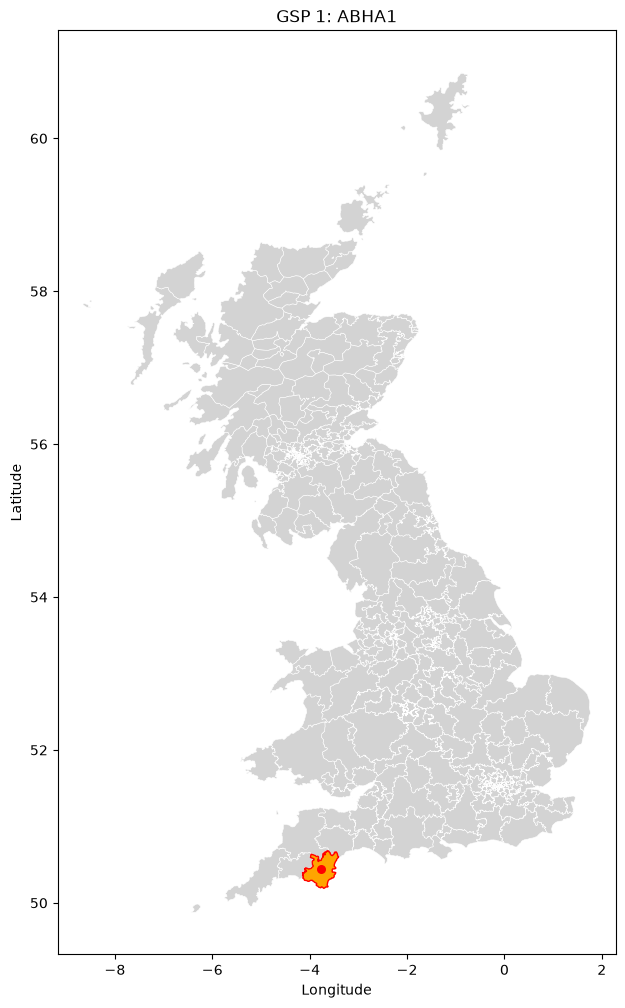

In [8]:
# want to get to this:

fig, ax = plt.subplots(figsize=(10,12))

gsp_regions.plot(
    ax=ax,
    facecolor='lightgrey',
    edgecolor='white',
    linewidth=0.4
)

selected_region.plot(
    ax=ax,
    facecolor='orange',
    edgecolor='red',
    linewidth=1
)

selected_region['centre'] = selected_region.geometry.centroid

selected_region['centre'].plot(
    ax=ax,
    color='red',
    markersize=30
)

ax.set_title('GSP 1: ABHA1')
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

In [9]:
gsp_regions.head()

,fid,GSPs,GSPGroup,SSEP17Zone,DSCPs,InGroup_,CDCA_I030,colour_index,colour_hex,ghi_instrument_count,has_ghi_instrument,gsp_id,gsp_name,datetime_gmt,capacity_mwp,geometry
0,1,LEGA_1,_D,7,NaN,Y,=GSP_LEGA_1,1,#377eb8,2,True,182.0,LEGA_1,2026-09-24 15:00:00+00:00,230.333,"MULTIPOLYGON (((-3.67528 52.3655, -3.67033 52...."
1,2,THSO_P,_P,1,NaN,Y,=GSP_THSO_P,1,#377eb8,1,True,288.0,THSO_P,2026-09-24 15:00:00+00:00,5.545,"MULTIPOLYGON (((-3.0732 58.73774, -3.07412 58...."
2,3,BRIM_1,_C,17,[+]BRIM_C,N,=II_BRIM_C,2,#4daf4a,0,False,40.0,BRIM_1,2026-09-24 15:00:00+00:00,40.393,"MULTIPOLYGON (((0.12638 51.59359, 0.12145 51.5..."
3,4,EERH,_N,4,NaN,Y,=GSP_EERH,0,#e41a1c,0,False,104.0,EERH,2026-09-24 15:00:00+00:00,12.054,"MULTIPOLYGON (((-4.1545 55.84639, -4.15447 55...."
4,5,AXMI1,_L,15,NaN,Y,=GSP_AXMI1,0,#e41a1c,0,False,13.0,AXMI1,2026-09-24 15:00:00+00:00,122.085,"MULTIPOLYGON (((-2.69894 50.68317, -2.69628 50..."


In [10]:
gsp_regions.columns.tolist()

['fid',
 'GSPs',
 'GSPGroup',
 'SSEP17Zone',
 'DSCPs',
 'InGroup_',
 'CDCA_I030',
 'colour_index',
 'colour_hex',
 'ghi_instrument_count',
 'has_ghi_instrument',
 'gsp_id',
 'gsp_name',
 'datetime_gmt',
 'capacity_mwp',
 'geometry']

### Step 2. Pull PV_Live data from that day (already done in 03 notebook)


In [11]:
gsp_id = 1

params = {
    'start': '2024-01-01T00:00:00',
    'end': '2024-01-02T00:00:00'
}

In [12]:
ts_response = requests.get(
    f"{API_BASE_URL}/gsp/{gsp_id}",
    params=params,
    timeout=30
)

In [13]:
ts_response

<Response [200]>

In [14]:
ts_response.raise_for_status()

In [15]:
payload1 = ts_response.json()

In [16]:
payload1

{'meta': ['gsp_id', 'datetime_gmt', 'generation_mw'],
 'data': [[1, '2024-01-02T00:00:00Z', 0.0],
  [1, '2024-01-01T23:30:00Z', 0.0],
  [1, '2024-01-01T23:00:00Z', 0.0],
  [1, '2024-01-01T22:30:00Z', 0.0],
  [1, '2024-01-01T22:00:00Z', 0.0],
  [1, '2024-01-01T21:30:00Z', 0.0],
  [1, '2024-01-01T21:00:00Z', 0.0],
  [1, '2024-01-01T20:30:00Z', 0.0],
  [1, '2024-01-01T20:00:00Z', 0.0],
  [1, '2024-01-01T19:30:00Z', 0.0],
  [1, '2024-01-01T19:00:00Z', 0.0],
  [1, '2024-01-01T18:30:00Z', 0.0],
  [1, '2024-01-01T18:00:00Z', 0.0],
  [1, '2024-01-01T17:30:00Z', 0.0],
  [1, '2024-01-01T17:00:00Z', 0.0],
  [1, '2024-01-01T16:30:00Z', 0.0],
  [1, '2024-01-01T16:00:00Z', 0.001],
  [1, '2024-01-01T15:30:00Z', 0.125],
  [1, '2024-01-01T15:00:00Z', 0.528],
  [1, '2024-01-01T14:30:00Z', 1.969],
  [1, '2024-01-01T14:00:00Z', 3.876],
  [1, '2024-01-01T13:30:00Z', 6.192],
  [1, '2024-01-01T13:00:00Z', 9.68],
  [1, '2024-01-01T12:30:00Z', 9.817],
  [1, '2024-01-01T12:00:00Z', 10.579],
  [1, '2024-01-01T11

In [17]:
type(payload1)

dict

In [18]:
hourly_data_gsp1 = pd.DataFrame(
    payload1.get('data'),
    columns= payload1.get('meta')
)
hourly_data_gsp1.head()


,gsp_id,datetime_gmt,generation_mw
0,1,2024-01-02T00:00:00Z,0.0
1,1,2024-01-01T23:30:00Z,0.0
2,1,2024-01-01T23:00:00Z,0.0
3,1,2024-01-01T22:30:00Z,0.0
4,1,2024-01-01T22:00:00Z,0.0


In [19]:
type(hourly_data_gsp1)

pandas.DataFrame

- So, now I have the PV_Live hourly data saved in a dataframe (just for this GSP and date)

### Step 3. Pull MIDAS data from that day


from 04 notebook: 
- Saved station availability summary to: ../data/outputs/MIDAS202607/station_2024_ghi_availability.csv


In [20]:
import csv
from pathlib import Path
import re
import numpy as np

In [21]:
# let's first load and inspect station metadata
# note that the metadata file contains coords but also explanatory text before the real header

MIDAS_DATA_PATH = Path("../data/inputs/MIDAS202607")
STATION_METADATA_PATH = MIDAS_DATA_PATH / "station-metadata.csv"

with STATION_METADATA_PATH.open(
    "r", # read
    # encoding=
    # errors=

) as file:
    metadata_lines = file.readlines()

metadata_header_row = next(
    i
    for i, line in enumerate(metadata_lines)
    if line.startswith("src_id,")
)
# So the line that starts with src_id is the start of the real data; the header column:
# src_id,station_name,station_file_name,historic_county,authority,station_latitude,station_longitude,station_elevation,first_year,last_year


MIDAS_2024_dataset = pd.read_csv(
    STATION_METADATA_PATH,
    skiprows=metadata_header_row
)



In [22]:
MIDAS_2024_dataset

,src_id,station_name,station_file_name,historic_county,authority,station_latitude,station_longitude,station_elevation,first_year,last_year
0,00003,FAIR ISLE,fair-isle,shetland,Met Office,59.526,-1.630,57.0,2011.0,2011.0
1,00009,LERWICK,lerwick,shetland,Met Office,60.139,-1.185,82.0,1952.0,2025.0
2,00012,BALTASOUND NO 2,baltasound-no-2,shetland,Met Office,60.748,-0.856,15.0,2010.0,2014.0
3,00023,KIRKWALL,kirkwall,orkney,Met Office,58.953,-2.901,26.0,2001.0,2025.0
4,00032,WICK AIRPORT,wick-airport,caithness,Met Office,58.454,-3.090,36.0,2011.0,2011.0
...,...,...,...,...,...,...,...,...,...,...
237,62122,ALMONDSBURY,almondsbury,avon,Met Office,51.551,-2.559,75.0,2018.0,2025.0
238,62139,WISLEY NO 2,wisley-no-2,surrey,Met Office,51.310,-0.475,38.0,2018.0,2021.0
239,62208,EXETER SURFACENET ENCLOSURE AWS,exeter-surfacenet-enclosure-aws,devon,Met Office,50.729,-3.475,0.0,2020.0,2025.0
240,62369,CLIFF FARM,cliff-farm,argyll-in-strathclyde-region,Met Office,56.759,-5.819,8.0,2025.0,2025.0


In [23]:
MIDAS_2024_dataset.columns.tolist()

['src_id',
 'station_name',
 'station_file_name',
 'historic_county',
 'authority',
 'station_latitude',
 'station_longitude',
 'station_elevation',
 'first_year',
 'last_year']

So, these metadata tell us where a station is. It doesn't say yet whether that station has valid data on the datetime we're considering (1 jan 2024)

In [24]:
import glob

# glob(): Return a list of paths matching a pathname pattern.

In [25]:
midas_2024_files = list(
    MIDAS_DATA_PATH.glob("**/*_2024.csv") # need to take a look at file structure to see the low-level csv's end with their YEAR.csv. asterisks are wildcards.
)

print(f"2024 files found: {len(midas_2024_files)}")
print(midas_2024_files[:3])

2024 files found: 164
[PosixPath('../data/inputs/MIDAS202607/inverness-shire/00113_aviemore/qc-version-1/midas-open_uk-radiation-obs_dv-202607_inverness-shire_00113_aviemore_qcv-1_2024.csv'), PosixPath('../data/inputs/MIDAS202607/inverness-shire/00113_aviemore/qc-version-0/midas-open_uk-radiation-obs_dv-202607_inverness-shire_00113_aviemore_qcv-0_2024.csv'), PosixPath('../data/inputs/MIDAS202607/inverness-shire/00105_tulloch-bridge/qc-version-1/midas-open_uk-radiation-obs_dv-202607_inverness-shire_00105_tulloch-bridge_qcv-1_2024.csv')]


Might have mulitple QC versions of some files, so should select highest QC version for each station

In [26]:
station_files = {} # creates a dictionary (empty so far)

for file_path in midas_2024_files: # take every filepath from midas_2024_files and temporarily call it file_path
    qc_directories = [
        part
        for part in file_path.parts # break the path into pieces ('parts', divided by slashes (/))
        if part.startswith("qc-version-")
    ]
    # construct qc_directories, which is a tuple containing the paths ONLY to folders starting with qc-version
    # so the only "part"s that get added to the tuple are those that satisfy the if statement

    if not qc_directories:
        continue
        # skip paths without a qc directory

    qc_version = int(
        qc_directories[-1].removeprefix("qc-version-") # take the last item in the list, remove the text, and convert to integer
    )

    station_key = file_path.parent.parent.name 
    # go up two directories and save that (grandparent's) part name, e.g. '00456_monks-wood' only

    current_file = station_files.get(station_key) # get is apparently safer than just using brackets because asking for a key that DNE yet would cause KeyError

    # decide wheter to store this file:
    if (current_file is None    or    qc_version > current_file[0]): # change > to < to take qc 0 instead!
        station_files[station_key] = (
            qc_version,
            file_path
        )
        # store this file IF either: we have not seen this station before (currently empty) OR the current file has a higher qc version than the one stored
        # I THINK I could update this whole logic to get the oldest one instead (qc v0) by changing the > to a < there!

selected_2024_files = []
for selected_file_info in station_files.values():
    qc_version = selected_file_info[0]
    file_path = selected_file_info[1]

    selected_2024_files.append(file_path)

print(f"Selected files: {len(selected_2024_files)}")

Selected files: 82


In [27]:
type(station_files)

dict

In [28]:
list(station_files.items())[:3] # because you can't do .head() with dicts since there's no ordering.

[('00113_aviemore',
  (1,
   PosixPath('../data/inputs/MIDAS202607/inverness-shire/00113_aviemore/qc-version-1/midas-open_uk-radiation-obs_dv-202607_inverness-shire_00113_aviemore_qcv-1_2024.csv'))),
 ('00105_tulloch-bridge',
  (1,
   PosixPath('../data/inputs/MIDAS202607/inverness-shire/00105_tulloch-bridge/qc-version-1/midas-open_uk-radiation-obs_dv-202607_inverness-shire_00105_tulloch-bridge_qcv-1_2024.csv'))),
 ('01005_auchincruive',
  (1,
   PosixPath('../data/inputs/MIDAS202607/ayrshire/01005_auchincruive/qc-version-1/midas-open_uk-radiation-obs_dv-202607_ayrshire_01005_auchincruive_qcv-1_2024.csv')))]

In [29]:
example_file = selected_2024_files[0]
example_file

PosixPath('../data/inputs/MIDAS202607/inverness-shire/00113_aviemore/qc-version-1/midas-open_uk-radiation-obs_dv-202607_inverness-shire_00113_aviemore_qcv-1_2024.csv')

^ we can see in the directory that inverness-shire has qc 0 and 1, and yet this path takes qc v1 which is good!



In [30]:
# But these CSV's still have many rows of text, so need to get to the actual data:

with example_file.open(
    "r"
) as file:
    example_lines = file.readlines()

observation_header_row = next(
    i
    for i, line in enumerate(example_lines)
    if line.startswith("ob_")
    and "glbl_irad_amt" in line.split(",") # comma delimited
)

print(observation_header_row) # 78; this means there are 77 rows above this which are just text; kind of annoying but maybe that metadata will be useful at some point
print(example_lines[observation_header_row][:300]) # 300 is the number of chars, not the number of columns

78
ob_end_time,id_type,id,ob_hour_count,version_num,met_domain_name,src_id,rec_st_ind,glbl_irad_amt,glbl_irad_amt_q,difu_irad_amt,difu_irad_amt_q,direct_irad,direct_irad_q,irad_bal_amt,irad_bal_amt_q,glbl_s_lat_irad_amt,glbl_s_lat_irad_amt_q,glbl_horz_ilmn,glbl_horz_ilmn_q,meto_stmp_time,midas_stmp_eti


In [31]:
example_data = pd.read_csv(
    example_file,
    skiprows= observation_header_row
)

example_data.head(24)
# Now it's a pandas dataFrame!

,ob_end_time,id_type,id,ob_hour_count,version_num,met_domain_name,src_id,rec_st_ind,glbl_irad_amt,glbl_irad_amt_q,...,direct_irad,direct_irad_q,irad_bal_amt,irad_bal_amt_q,glbl_s_lat_irad_amt,glbl_s_lat_irad_amt_q,glbl_horz_ilmn,glbl_horz_ilmn_q,meto_stmp_time,midas_stmp_etime
0,2024-01-01 00:00:00,DCNN,585.0,1.0,1.0,HCM,113.0,1011.0,0.0,6.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2024-01-01 00:03:00,0.0
1,2024-01-01 01:00:00,DCNN,585.0,1.0,1.0,HCM,113.0,1011.0,0.0,6.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2024-01-01 01:03:00,0.0
2,2024-01-01 02:00:00,DCNN,585.0,1.0,1.0,HCM,113.0,1011.0,0.0,6.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2024-01-01 02:03:00,0.0
3,2024-01-01 03:00:00,DCNN,585.0,1.0,1.0,HCM,113.0,1011.0,0.0,6.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2024-01-01 03:03:00,0.0
4,2024-01-01 04:00:00,DCNN,585.0,1.0,1.0,HCM,113.0,1011.0,0.0,6.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2024-01-01 04:03:00,0.0
5,2024-01-01 05:00:00,DCNN,585.0,1.0,1.0,HCM,113.0,1011.0,0.0,6.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2024-01-01 05:03:00,0.0
6,2024-01-01 06:00:00,DCNN,585.0,1.0,1.0,HCM,113.0,1011.0,0.0,6.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2024-01-01 06:03:00,0.0
7,2024-01-01 07:00:00,DCNN,585.0,1.0,1.0,HCM,113.0,1011.0,0.0,6.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2024-01-01 07:03:00,0.0
8,2024-01-01 08:00:00,DCNN,585.0,1.0,1.0,HCM,113.0,1011.0,0.0,6.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2024-01-01 08:03:00,0.0
9,2024-01-01 09:00:00,DCNN,585.0,1.0,1.0,HCM,113.0,1011.0,0.0,6.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2024-01-01 09:03:00,0.0


^ okay so this looks good! I can see 24hrs of glbl_irad_amt data, which peaks around noon

In [32]:
# Let's define this glbl_irad_amt as GHI

GHI_FIELD = "glbl_irad_amt"

Now let's find stations with data on 1 Jan 2024

In [33]:
FOCUS_DATE = "2024-01-01"

#  defining a function which reads the midas observations (skipping the wall of useless text up top of the CSV)

def read_midas_observations(file_path):
    with file_path.open(
        "r",
        # could add encoding and errors here
    ) as file:
        lines = file.readlines()

    header_row = next(
        i
        for i, line in enumerate(lines)
        if line.startswith("ob_") # needed to check the contents of the CSV, hopefully they all have this pattern where the data finally starts with 'ob_end_time'
        and GHI_FIELD in line.split(",")
    )

    return pd.read_csv(
        file_path,
        skiprows=header_row
    )

In [34]:
selected_2024_files

[PosixPath('../data/inputs/MIDAS202607/inverness-shire/00113_aviemore/qc-version-1/midas-open_uk-radiation-obs_dv-202607_inverness-shire_00113_aviemore_qcv-1_2024.csv'),
 PosixPath('../data/inputs/MIDAS202607/inverness-shire/00105_tulloch-bridge/qc-version-1/midas-open_uk-radiation-obs_dv-202607_inverness-shire_00105_tulloch-bridge_qcv-1_2024.csv'),
 PosixPath('../data/inputs/MIDAS202607/ayrshire/01005_auchincruive/qc-version-1/midas-open_uk-radiation-obs_dv-202607_ayrshire_01005_auchincruive_qcv-1_2024.csv'),
 PosixPath('../data/inputs/MIDAS202607/ayrshire/01007_prestwick-gannet/qc-version-1/midas-open_uk-radiation-obs_dv-202607_ayrshire_01007_prestwick-gannet_qcv-1_2024.csv'),
 PosixPath('../data/inputs/MIDAS202607/renfrewshire/24125_glasgow-bishopton/qc-version-1/midas-open_uk-radiation-obs_dv-202607_renfrewshire_24125_glasgow-bishopton_qcv-1_2024.csv'),
 PosixPath('../data/inputs/MIDAS202607/suffolk/00440_wattisham/qc-version-1/midas-open_uk-radiation-obs_dv-202607_suffolk_00440_wa

In [35]:
#  now let's loop through the selected station files:

midas_jan1_records = []

for file_path in selected_2024_files:
    station_data = read_midas_observations(file_path)

    datetime_column = "ob_end_time" # NOTE THAT IT'S THE END TIME, NOT START TIME!

    if datetime_column is None:
        continue

    station_data[datetime_column] = pd.to_datetime(
            station_data[datetime_column],
            errors='coerce', # so these are really important it seems!
            # format='mixed' # tried this on my own but it didn't help. hopefully i'm not losing data just because the datetime format for some of them is weird
        )

    station_data[GHI_FIELD] = pd.to_numeric(
        station_data[GHI_FIELD],
        errors='coerce'
    )

    jan1 = station_data[
        station_data[datetime_column].dt.date == pd.Timestamp(FOCUS_DATE).date()
    ].copy()

    jan1 = jan1.dropna(subset=[datetime_column, GHI_FIELD])

    if jan1.empty:
        continue

    station_folder = file_path.parent.parent.name

    station_id, _, station_name = (station_folder.partition("_"))

    midas_jan1_records.append(
        {
            "station_id": station_id,
            "station_name": station_name,
            "file_path": file_path,
            "datetime_column": datetime_column,
            "observations": jan1,
        }
    )

print("Stations with valid GHI data on 1 Jan 2024:", len(midas_jan1_records))

Stations with valid GHI data on 1 Jan 2024: 81


In [36]:
midas_jan1_records

[{'station_id': '00113',
  'station_name': 'aviemore',
  'file_path': PosixPath('../data/inputs/MIDAS202607/inverness-shire/00113_aviemore/qc-version-1/midas-open_uk-radiation-obs_dv-202607_inverness-shire_00113_aviemore_qcv-1_2024.csv'),
  'datetime_column': 'ob_end_time',
  'observations':            ob_end_time id_type      id  ob_hour_count  version_num  \
  0  2024-01-01 00:00:00    DCNN   585.0            1.0          1.0   
  1  2024-01-01 01:00:00    DCNN   585.0            1.0          1.0   
  2  2024-01-01 02:00:00    DCNN   585.0            1.0          1.0   
  3  2024-01-01 03:00:00    DCNN   585.0            1.0          1.0   
  4  2024-01-01 04:00:00    DCNN   585.0            1.0          1.0   
  5  2024-01-01 05:00:00    DCNN   585.0            1.0          1.0   
  6  2024-01-01 06:00:00    DCNN   585.0            1.0          1.0   
  7  2024-01-01 07:00:00    DCNN   585.0            1.0          1.0   
  8  2024-01-01 08:00:00    DCNN   585.0            1.0      

In [37]:
# make a station summary table - first, prep the metadata id's

MIDAS_2024_dataset["station_id"] = (
    MIDAS_2024_dataset["src_id"]
    .astype(str) # converts the data in the src_id column into strings
    .str.extract(r"(\d+)")[0] #regular expression (regex) to look at each row. \d means find a digit, + means find one or more of them in a row, () capture matched group of #'s.
)

# extracts only the digits from the column src_id and saves them in a NEW COLUMN called station_id in the pandas df MIDAS_2024_dataset

In [38]:
MIDAS_2024_dataset

,src_id,station_name,station_file_name,historic_county,authority,station_latitude,station_longitude,station_elevation,first_year,last_year,station_id
0,00003,FAIR ISLE,fair-isle,shetland,Met Office,59.526,-1.630,57.0,2011.0,2011.0,00003
1,00009,LERWICK,lerwick,shetland,Met Office,60.139,-1.185,82.0,1952.0,2025.0,00009
2,00012,BALTASOUND NO 2,baltasound-no-2,shetland,Met Office,60.748,-0.856,15.0,2010.0,2014.0,00012
3,00023,KIRKWALL,kirkwall,orkney,Met Office,58.953,-2.901,26.0,2001.0,2025.0,00023
4,00032,WICK AIRPORT,wick-airport,caithness,Met Office,58.454,-3.090,36.0,2011.0,2011.0,00032
...,...,...,...,...,...,...,...,...,...,...,...
237,62122,ALMONDSBURY,almondsbury,avon,Met Office,51.551,-2.559,75.0,2018.0,2025.0,62122
238,62139,WISLEY NO 2,wisley-no-2,surrey,Met Office,51.310,-0.475,38.0,2018.0,2021.0,62139
239,62208,EXETER SURFACENET ENCLOSURE AWS,exeter-surfacenet-enclosure-aws,devon,Met Office,50.729,-3.475,0.0,2020.0,2025.0,62208
240,62369,CLIFF FARM,cliff-farm,argyll-in-strathclyde-region,Met Office,56.759,-5.819,8.0,2025.0,2025.0,62369


^ see the new station_id column at the far right. 242 rows, though i guess this is for all of 2024

In [39]:
MIDAS_2024_dataset.head(10)

,src_id,station_name,station_file_name,historic_county,authority,station_latitude,station_longitude,station_elevation,first_year,last_year,station_id
0,00003,FAIR ISLE,fair-isle,shetland,Met Office,59.526,-1.630,57.0,2011.0,2011.0,00003
1,00009,LERWICK,lerwick,shetland,Met Office,60.139,-1.185,82.0,1952.0,2025.0,00009
2,00012,BALTASOUND NO 2,baltasound-no-2,shetland,Met Office,60.748,-0.856,15.0,2010.0,2014.0,00012
3,00023,KIRKWALL,kirkwall,orkney,Met Office,58.953,-2.901,26.0,2001.0,2025.0,00023
4,00032,WICK AIRPORT,wick-airport,caithness,Met Office,58.454,-3.090,36.0,2011.0,2011.0,00032
5,00040,CASSLEY,cassley,sutherland,Met Office,58.168,-4.727,99.0,2001.0,2003.0,00040
6,00044,ALTNAHARRA NO 2,altnaharra-no-2,sutherland,Met Office,58.288,-4.442,81.0,1993.0,2025.0,00044
7,00048,"KINBRACE, HATCHERY",kinbrace-hatchery,sutherland,Met Office,58.230,-3.922,103.0,1999.0,2025.0,00048
8,00052,AULTBEA NO 2,aultbea-no-2,ross-and-cromarty,Met Office,57.859,-5.633,11.0,2006.0,2011.0,00052
9,00054,STORNOWAY AIRPORT,stornoway-airport,western-isles,Met Office,58.213,-6.319,15.0,1982.0,2025.0,00054


In [40]:
# create one row per available station

available_station_ids = [
    record["station_id"]
    for record in midas_jan1_records
]

midas_stations_jan1 = (
    MIDAS_2024_dataset[
        MIDAS_2024_dataset['station_id'].isin(
            available_station_ids
        )
    ][
        [
            'station_id',
            'station_latitude',
            'station_longitude'
        ]
    ]
    .drop_duplicates('station_id')
    .copy()
)

In [41]:
len(available_station_ids)

81

In [42]:
midas_stations_jan1

,station_id,station_latitude,station_longitude
1,00009,60.139,-1.185
3,00023,58.953,-2.901
6,00044,58.288,-4.442
7,00048,58.230,-3.922
9,00054,58.213,-6.319
...,...,...,...
234,57199,53.360,-2.382
235,61986,52.457,1.162
236,62041,50.737,-3.406
237,62122,51.551,-2.559


^ okay good so we have the 81 again.

In [43]:
type(midas_stations_jan1)

pandas.DataFrame

In [ ]:
# Next: plot these on the existing GSP map (where I have ABHA1 plotted)

In [ ]:
midas_points_jan1 = gpd.GeoDataFrame(
    midas_stations_jan1,
    geometry = gpd.points_from_xy(
        midas_stations_jan1['station_longitude'],
        midas_stations_jan1['station_latitude'],
    ),
    crs='EPSG:4326', # curious to see what this would do if I didn't define the crs. it seemed to make no difference tbh
)

# I'm not sure why this was necessary; I guess because the lat/long points were just saved in a table and not in a geodataframe which can readily be plotted?

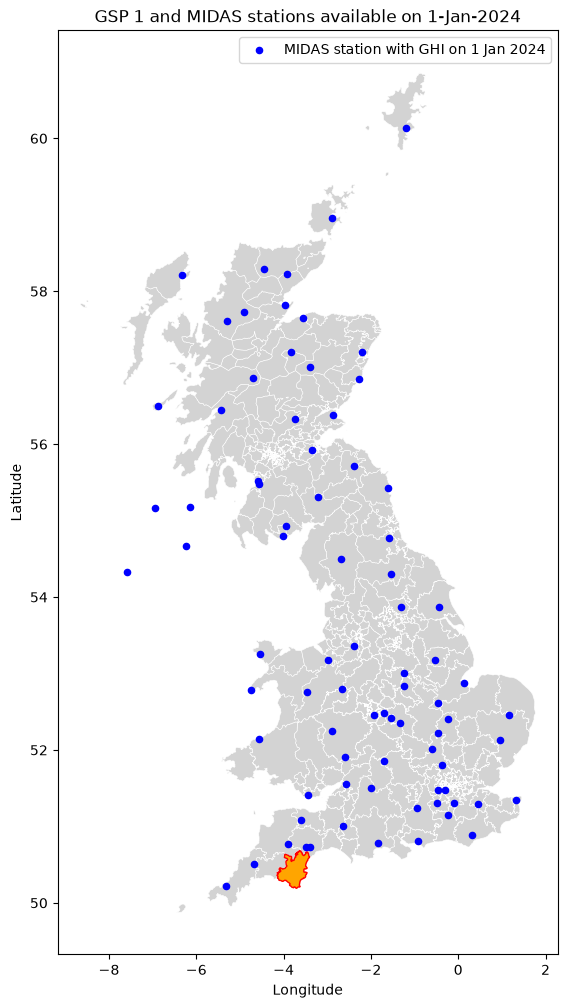

In [58]:
fig, ax = plt.subplots(figsize=(10,12))

gsp_regions.plot(
    ax=ax,
    facecolor='lightgrey',
    edgecolor='white',
    linewidth=0.4,
)

selected_region.plot(
    ax=ax,
    facecolor='orange',
    edgecolor='red',
    linewidth=1
)

midas_points_jan1.plot(
    ax=ax,
    color='blue',
    markersize=20,
    label='MIDAS station with GHI on 1 Jan 2024',
)

ax.set_title('GSP 1 and MIDAS stations available on 1-Jan-2024')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.legend()
# plt.show()

Nice. Good showing ^
- Now let's think about the distances

In [ ]:
# for meaningful distances, we'll convert from degrees to metres. Brit Nat Grid 27700 is suitable for GB

selected_region_projected = selected_region.to_crs('EPSG:27700') # still looking at that first gsp region (ABHA1)
midas_points_projected = midas_points_jan1.to_crs('EPSG:27700')

In [85]:
# try computing representative point and centroid, compare
gsp_reference_point = selected_region_projected.geometry.representative_point().iloc[0] # similar to centroid but must be in the shape

# let's take a look at where the centroid would put it, too

gsp_centroid_point = selected_region_projected.geometry.centroid.iloc[0] # don't need the () after centroid for some reason; it is a property, whereas rep_point() is a method

In [86]:
type(gsp_reference_point)

shapely.geometry.point.Point

In [87]:
type(gsp_centroid_point)

# So, they're shapely point objects (because extracted via .iloc[0]), not geodataframes. they do not have a .plot() method. should instead use standard matplotlib ax.scatter() to draw the points

shapely.geometry.point.Point

In [88]:
# instead, let's keep them as geodataframes to use native .plot() syntax

repr_series = selected_region_projected.geometry.representative_point()
centr_series = selected_region_projected.geometry.centroid

gsp_reference_point_gdf = gpd.GeoDataFrame(geometry=repr_series, crs=selected_region_projected.crs)
gsp_centroid_point_gdf = gpd.GeoDataFrame(geometry=centr_series, crs=selected_region_projected.crs)

# though for plotting, need to reproject the points to match the main map layer (gsp_regions)
gsp_reference_point_mapped = gsp_reference_point_gdf.to_crs(gsp_regions.crs)
gsp_centroid_point_mapped = gsp_centroid_point_gdf.to_crs(gsp_regions.crs)

In [89]:
type(gsp_reference_point_gdf) # now it's a geodataframe

geopandas.geodataframe.GeoDataFrame

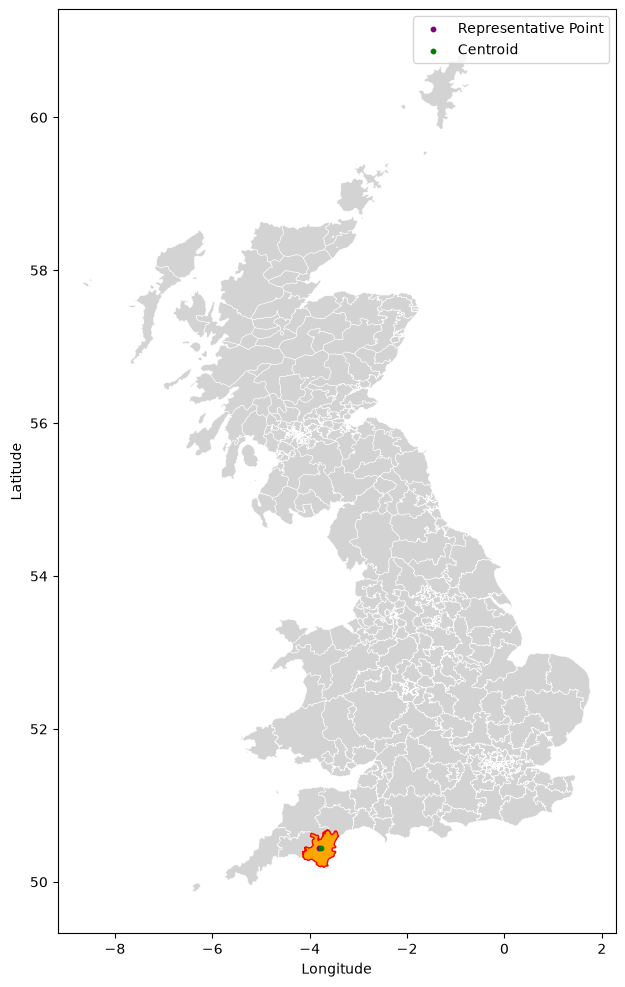

In [90]:
# let's see the difference between centroid and representative pt
fig, ax = plt.subplots(figsize=(10,12))

gsp_regions.plot(
    ax=ax,
    facecolor='lightgrey',
    edgecolor='white',
    linewidth=0.4,
)

selected_region.plot(
    ax=ax,
    facecolor='orange',
    edgecolor='red',
    linewidth=1
)

gsp_reference_point_mapped.plot(
    ax=ax,
    color='purple',
    markersize=10,
    label='Representative Point',
)

gsp_centroid_point_mapped.plot(
    ax=ax,
    color='green',
    markersize=10,
    label='Centroid',
)

ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.legend()

So, very very similar.though it may be much different for cresent-shaped or other weirdly-shaped regions.
- Anyways, back to the task at hand, of inspecting the distances

In [ ]:
type(gsp_reference_point) # this one is still shapely, to be used for the metres distance calculations

shapely.geometry.point.Point

In [93]:
# calculate the distance to every MIDAS station

midas_points_projected['distance_km'] = midas_points_projected.geometry.distance(gsp_reference_point)/1000 # natively in metres

In [ ]:
# sort by distance

closest_midas = midas_points_projected.sort_values('distance_km')

closest_midas[['station_id', 'distance_km']].head(10) # top 10 closest MIDAS stations to the rep point of the ABHA1 GSP 
# though admittedly they could be much closer to the border of the region or closer to where most of the installed PV is -- we just don't know tbh
# could also consider the location of the gsp's actual substation

# OOOH -- POSSIBLE NEW RESEARCH AREA: could augment the model further by taking into account the location(s) of PV within the GSP regions. Could do some weighted averaging or even involve some unsupervised clustering

,station_id,distance_km
168,01352,37.194748
239,62208,40.234696
236,62041,44.002468
175,01415,60.849753
163,01285,73.489114
164,01302,104.028039
174,01395,110.483964
214,19206,110.580146
108,00842,145.072327
237,62122,151.856313


In [96]:
# now, let's select the closest 3 stations and retrieve their hourly GHI observations

closest_three = closest_midas.head(3)
closest_three[['station_id','distance_km']]

,station_id,distance_km
168,01352,37.194748
239,62208,40.234696
236,62041,44.002468


In [97]:
type(closest_three)

geopandas.geodataframe.GeoDataFrame

In [98]:
closest_three

,station_id,station_latitude,station_longitude,geometry,distance_km
168,01352,50.769,-3.904,POINT (265832.111 98330.364),37.194748
239,62208,50.729,-3.475,POINT (295993.643 93191.317),40.234696
236,62041,50.737,-3.406,POINT (300880.24 93986.061),44.002468


RECALL THAT THIS 'DISTANCE' IS MERELY THEIR DISTANCE TO THE ABHA1 GSP REP_POINT; THEY MAY BE CLOSER TO OTHER GSP REGIONS (and in fact they almost certainly are)

In [102]:
midas_record_lookup = {}

for record in midas_jan1_records:
    midas_record_lookup[record['station_id']] = record
# takes a list of records (midas_jan1_records, which is a list), and converts it to a dictionary, where each key is a station ID and each value is the corresponding record

In [103]:
type(midas_jan1_records) # list
midas_jan1_records

[{'station_id': '00113',
  'station_name': 'aviemore',
  'file_path': PosixPath('../data/inputs/MIDAS202607/inverness-shire/00113_aviemore/qc-version-1/midas-open_uk-radiation-obs_dv-202607_inverness-shire_00113_aviemore_qcv-1_2024.csv'),
  'datetime_column': 'ob_end_time',
  'observations':            ob_end_time id_type      id  ob_hour_count  version_num  \
  0  2024-01-01 00:00:00    DCNN   585.0            1.0          1.0   
  1  2024-01-01 01:00:00    DCNN   585.0            1.0          1.0   
  2  2024-01-01 02:00:00    DCNN   585.0            1.0          1.0   
  3  2024-01-01 03:00:00    DCNN   585.0            1.0          1.0   
  4  2024-01-01 04:00:00    DCNN   585.0            1.0          1.0   
  5  2024-01-01 05:00:00    DCNN   585.0            1.0          1.0   
  6  2024-01-01 06:00:00    DCNN   585.0            1.0          1.0   
  7  2024-01-01 07:00:00    DCNN   585.0            1.0          1.0   
  8  2024-01-01 08:00:00    DCNN   585.0            1.0      

In [ ]:
# now combine the closest stations' observations:

closest_midas_hourly = [] # making a list

for station_id in closest_three['station_id']:
    record = midas_record_lookup[station_id]

    station_observations = record['observations'].copy()

    datetime_column = record['datetime_column']

    station_observations = station_observations[[datetime_column, GHI_FIELD]].rename(
        columns = {
            datetime_column: 'datetime_gmt', 
            GHI_FIELD: f'ghi_{station_id}'}
    ) 
    # give each midas station its own title of the form 'ghi_{id here}'

    station_observations['datetime_gmt'] = (
        pd.to_datetime(
            station_observations['datetime_gmt'],
            utc=True,
        )
    )
    # and put it in gmt time (already was -- not sure how daylight savings will act yet)

    closest_midas_hourly.append(
        station_observations.set_index('datetime_gmt')
    )

In [109]:
type(closest_midas_hourly)

list

In [112]:
closest_midas_hourly

[                           ghi_01352
 datetime_gmt                        
 2024-01-01 00:00:00+00:00        0.0
 2024-01-01 01:00:00+00:00        0.0
 2024-01-01 02:00:00+00:00        0.0
 2024-01-01 03:00:00+00:00        0.0
 2024-01-01 04:00:00+00:00        0.0
 2024-01-01 05:00:00+00:00        0.0
 2024-01-01 06:00:00+00:00        0.0
 2024-01-01 07:00:00+00:00        0.0
 2024-01-01 08:00:00+00:00        0.0
 2024-01-01 09:00:00+00:00       29.0
 2024-01-01 10:00:00+00:00      196.0
 2024-01-01 11:00:00+00:00      310.0
 2024-01-01 12:00:00+00:00      421.0
 2024-01-01 13:00:00+00:00      434.0
 2024-01-01 14:00:00+00:00      368.0
 2024-01-01 15:00:00+00:00      121.0
 2024-01-01 16:00:00+00:00       29.0
 2024-01-01 17:00:00+00:00        0.0
 2024-01-01 18:00:00+00:00        0.0
 2024-01-01 19:00:00+00:00        0.0
 2024-01-01 20:00:00+00:00        0.0
 2024-01-01 21:00:00+00:00        0.0
 2024-01-01 22:00:00+00:00        0.0
 2024-01-01 23:00:00+00:00        0.0
 2024-01-01 

In [113]:
# ^ not sure why we'd want it in only one column (though I guess it's a list rn)

closest_midas_hourly = pd.concat(closest_midas_hourly, axis=1).reset_index()

In [114]:
closest_midas_hourly

,datetime_gmt,ghi_01352,ghi_62208,ghi_62041
0,2024-01-01 00:00:00+00:00,0.0,0.0,0.0
1,2024-01-01 01:00:00+00:00,0.0,0.0,0.0
2,2024-01-01 02:00:00+00:00,0.0,0.0,0.0
3,2024-01-01 03:00:00+00:00,0.0,0.0,0.0
4,2024-01-01 04:00:00+00:00,0.0,0.0,0.0
5,2024-01-01 05:00:00+00:00,0.0,0.0,0.0
6,2024-01-01 06:00:00+00:00,0.0,0.0,0.0
7,2024-01-01 07:00:00+00:00,0.0,0.0,0.0
8,2024-01-01 08:00:00+00:00,0.0,0.0,0.0
9,2024-01-01 09:00:00+00:00,29.0,28.0,27.0


In [ ]:
# nice, now it is a dataframe with separate columns per station

# NOTE that there is a NaN value in one of the stations. That is a bit worrisome. I'm also not sure why there is a 23:59 value which looks to be a sum; it wouldn't make sense otherwise to have high irradiance values at midnight
type(closest_midas_hourly)

pandas.DataFrame

In [131]:
closest_midas_hourly['ghi_01352'].sum() - closest_midas_hourly['ghi_01352'].iloc[-1]

np.float64(1908.0)

In [130]:
closest_midas_hourly['ghi_01352'].iloc[-1]

np.float64(1909.0)

^ not sure why it disagrees slightly but I guess it is a sum.

In [ ]:
closest_midas_hourly['ghi_62041'].sum() - closest_midas_hourly['ghi_62041'].iloc[-1] # this one agrees exactly

np.float64(1664.0)

Note from CSV files:
- long_name,glbl_irad_amt,Global solar irradiation amount,KJ/m2
- type,glbl_irad_amt,int

### Now, let's inspect PVLive columns before plotting together

In [116]:
hourly_data_gsp1.columns.tolist()

['gsp_id', 'datetime_gmt', 'generation_mw']

In [117]:
hourly_data_gsp1.dtypes

gsp_id             int64
datetime_gmt         str
generation_mw    float64
dtype: object

In [118]:
# may need to convert pvlive datetime data to pd datetime:

hourly_data_gsp1['datetime_gmt'] = pd.to_datetime(hourly_data_gsp1['datetime_gmt'], utc=True)

In [119]:
hourly_data_gsp1.dtypes

gsp_id                         int64
datetime_gmt     datetime64[us, UTC]
generation_mw                float64
dtype: object

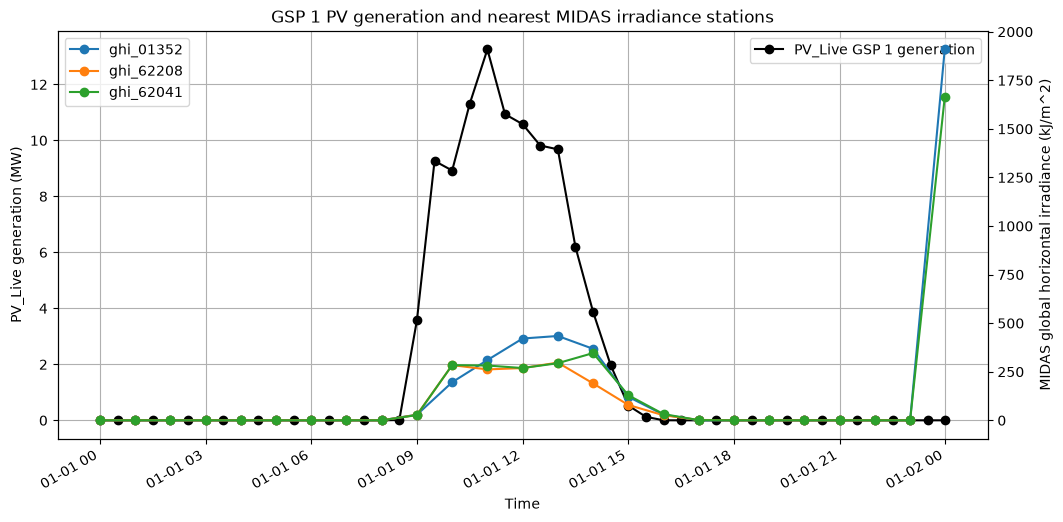

In [145]:
# ^ okay good now it's a datetime datatype in UTC

# Finally, let's plot PVLive and MIDAS together (and inspect that wacky 23:59 stuff from above)
# note:
#   - pvlive generation in MW, half-hourly
#   - MIDAS GHI data in kJ/m^2

fig, ax_pv = plt.subplots(figsize=(12,6))

ax_pv.plot(
    hourly_data_gsp1['datetime_gmt'],
    hourly_data_gsp1['generation_mw'],
    color='black',
    marker='o',
    label='PV_Live GSP 1 generation'
)

ax_pv.set_xlabel('Time') 
ax_pv.set_ylabel('PV_Live generation (MW)')
ax_pv.grid(True)

ax_ghi = ax_pv.twinx()

for column in closest_midas_hourly.columns:
    if column.startswith('ghi_'):
        ax_ghi.plot(
            closest_midas_hourly['datetime_gmt'],
            closest_midas_hourly[column],
            marker='o',
            label=column
        )

ax_ghi.set_ylabel('MIDAS global horizontal irradiance (kJ/m^2)')
ax_pv.set_title('GSP 1 PV generation and nearest MIDAS irradiance stations')
ax_pv.legend()
ax_ghi.legend()

fig.autofmt_xdate()



^ okay good so what can we see:
- GOOD: the GHI are showing up hourly while the PV_Live is half-hourly
- GOOD: I'm getting all the data (I think)
- BAD: at midnight, there is a spike for two of the GHI datasets (might be the sum), and one of the datasets has a NaN in that slot
- MAYBE BAD: why isn't the alignment agreeing; why does PV generation go so high so much earlier than the generation does?

Let's investigate that weird sum row:

In [146]:
record = midas_record_lookup['01352']

record['observations'][['ob_end_time', GHI_FIELD]].tail()

,ob_end_time,glbl_irad_amt
20,2024-01-01 20:00:00,0.0
21,2024-01-01 21:00:00,0.0
22,2024-01-01 22:00:00,0.0
23,2024-01-01 23:00:00,0.0
24,2024-01-01 23:59:00,1909.0


In [147]:
record['observations'].tail(1) # all of the columns for this record. Can do '.T. to transpose to column vector

,ob_end_time,id_type,id,ob_hour_count,version_num,met_domain_name,src_id,rec_st_ind,glbl_irad_amt,glbl_irad_amt_q,...,direct_irad,direct_irad_q,irad_bal_amt,irad_bal_amt_q,glbl_s_lat_irad_amt,glbl_s_lat_irad_amt_q,glbl_horz_ilmn,glbl_horz_ilmn_q,meto_stmp_time,midas_stmp_etime
24,2024-01-01 23:59:00,DCNN,8836.0,24.0,1.0,AWSHRLY,1352.0,1011.0,1909.0,6.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2024-01-02 00:03:00,NaN


In [148]:
# where are these midas data coming from exactly:

for station_id in closest_three['station_id']:
    record = midas_record_lookup[station_id]
    print(station_id)
    print(record['station_name'])
    print(record['file_path'])
    print() # blank space

01352
north-wyke
../data/inputs/MIDAS202607/devon/01352_north-wyke/qc-version-1/midas-open_uk-radiation-obs_dv-202607_devon_01352_north-wyke_qcv-1_2024.csv

62208
exeter-surfacenet-enclosure-aws
../data/inputs/MIDAS202607/devon/62208_exeter-surfacenet-enclosure-aws/qc-version-1/midas-open_uk-radiation-obs_dv-202607_devon_62208_exeter-surfacenet-enclosure-aws_qcv-1_2024.csv

62041
exeter-airport-no-2
../data/inputs/MIDAS202607/devon/62041_exeter-airport-no-2/qc-version-1/midas-open_uk-radiation-obs_dv-202607_devon_62041_exeter-airport-no-2_qcv-1_2024.csv



/Users/mans5211/GitHub-repos/Met-Office-Solar-Luke/data/inputs/MIDAS202607/devon/01352_north-wyke/qc-version-1/midas-open_uk-radiation-obs_dv-202607_devon_01352_north-wyke_qcv-1_2024.csv
- Wow so I guess some of these CSV's just silently include daily sums under the 23:59 timestamp. Bizarre.
- So, to compensate for this, I will filter to only timestamps that end in minute 00
    - could  do:
    `station_observations['datetime_gmt'].dt.minute == 0`
    `station_observations["datetime_gmt"].dt.time != pd.Timestamp("23:59:00").time()`
    - to explicitly remove the 23:59 instances...

In [153]:
station_observations = station_observations[
    station_observations["datetime_gmt"].dt.time != pd.Timestamp("23:59:00").time()
].copy()

In [152]:
station_observations

,datetime_gmt,ghi_62041
0,2024-01-01 00:00:00+00:00,0.0
1,2024-01-01 01:00:00+00:00,0.0
2,2024-01-01 02:00:00+00:00,0.0
3,2024-01-01 03:00:00+00:00,0.0
4,2024-01-01 04:00:00+00:00,0.0
5,2024-01-01 05:00:00+00:00,0.0
6,2024-01-01 06:00:00+00:00,0.0
7,2024-01-01 07:00:00+00:00,0.0
8,2024-01-01 08:00:00+00:00,0.0
9,2024-01-01 09:00:00+00:00,27.0


### Corrected time series (summary rows removed):

In [ ]:
corrected_midas_hourly_list = []

for station_id in closest_three['station_id']:
    record = midas_record_lookup[station_id]

    station_observations = record['observations'].copy()
    datetime_column = record['datetime_column']

    station_observations = station_observations[
        [datetime_column, GHI_FIELD]
    ].rename(columns = {
        datetime_column: 'datetime_gmt',
        GHI_FIELD: f'ghi_{station_id}',
        }
    )

    station_observations['datetime_gmt'] = pd.to_datetime(
        station_observations['datetime_gmt'],
        utc=True
    )

    # now we remove the daily summary timestamp
    station_observations = station_observations[
        station_observations['datetime_gmt'].dt.strftime('%H:%M') != '23:59'
    ].copy()

    corrected_midas_hourly_list.append(
        station_observations.set_index('datetime_gmt')
    )

In [159]:
# and finally combine in a pd dataframe

corrected_midas_hourly = pd.concat(corrected_midas_hourly_list, axis=1).reset_index()

In [161]:
corrected_midas_hourly

,datetime_gmt,ghi_01352,ghi_62208,ghi_62041
0,2024-01-01 00:00:00+00:00,0.0,0.0,0.0
1,2024-01-01 01:00:00+00:00,0.0,0.0,0.0
2,2024-01-01 02:00:00+00:00,0.0,0.0,0.0
3,2024-01-01 03:00:00+00:00,0.0,0.0,0.0
4,2024-01-01 04:00:00+00:00,0.0,0.0,0.0
5,2024-01-01 05:00:00+00:00,0.0,0.0,0.0
6,2024-01-01 06:00:00+00:00,0.0,0.0,0.0
7,2024-01-01 07:00:00+00:00,0.0,0.0,0.0
8,2024-01-01 08:00:00+00:00,0.0,0.0,0.0
9,2024-01-01 09:00:00+00:00,29.0,28.0,27.0


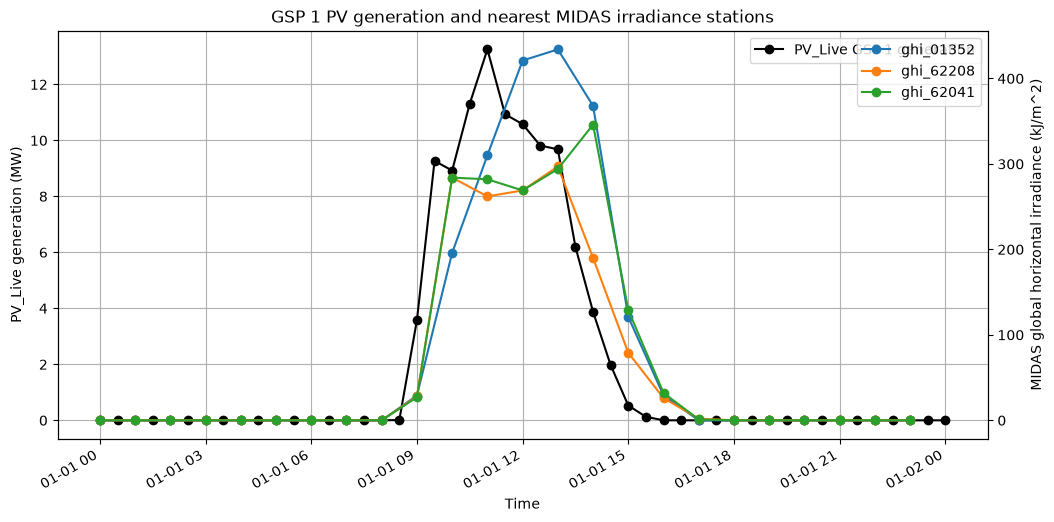

In [162]:
# (borrowed code from above, but using corrected_midas_hourly)

# Finally, let's plot PVLive and MIDAS together (and inspect that wacky 23:59 stuff from above)
# note:
#   - pvlive generation in MW, half-hourly
#   - MIDAS GHI data in kJ/m^2

fig, ax_pv = plt.subplots(figsize=(12,6))

ax_pv.plot(
    hourly_data_gsp1['datetime_gmt'],
    hourly_data_gsp1['generation_mw'],
    color='black',
    marker='o',
    label='PV_Live GSP 1 generation'
)

ax_pv.set_xlabel('Time') 
ax_pv.set_ylabel('PV_Live generation (MW)')
ax_pv.grid(True)

ax_ghi = ax_pv.twinx()

for column in corrected_midas_hourly.columns:
    if column.startswith('ghi_'):
        ax_ghi.plot(
            corrected_midas_hourly['datetime_gmt'],
            corrected_midas_hourly[column],
            marker='o',
            label=column
        )

ax_ghi.set_ylabel('MIDAS global horizontal irradiance (kJ/m^2)')
ax_pv.set_title('GSP 1 PV generation and nearest MIDAS irradiance stations')
ax_pv.legend()
ax_ghi.legend()

fig.autofmt_xdate()



In [165]:
# add W/m^2

# Make a separate copy so the original kJ/m² data remains available.
corrected_midas_hourly_wm2 = (
    corrected_midas_hourly.copy()
)

# Find the MIDAS irradiance columns.
ghi_columns = [
    column
    for column in corrected_midas_hourly_wm2.columns
    if column.startswith("ghi_")
]

# Convert hourly energy from kJ/m² to average power in W/m².
#
# 1 kJ = 1,000 joules
# 1 hour = 3,600 seconds
# Therefore:
# 1 kJ/m² per hour = 1,000 / 3,600 W/m²
#                  = 1 / 3.6 W/m²
for column in ghi_columns:
    corrected_midas_hourly_wm2[column] = (
        corrected_midas_hourly_wm2[column] / 3.6
    )

# Rename the converted columns so their units are obvious.
corrected_midas_hourly_wm2 = (
    corrected_midas_hourly_wm2.rename(
        columns={
            column: f"{column}_wm2"
            for column in ghi_columns
        }
    )
)

# Inspect the converted data.
corrected_midas_hourly_wm2.head(14)

,datetime_gmt,ghi_01352_wm2,ghi_62208_wm2,ghi_62041_wm2
0,2024-01-01 00:00:00+00:00,0.000000,0.000000,0.000000
1,2024-01-01 01:00:00+00:00,0.000000,0.000000,0.000000
2,2024-01-01 02:00:00+00:00,0.000000,0.000000,0.000000
3,2024-01-01 03:00:00+00:00,0.000000,0.000000,0.000000
4,2024-01-01 04:00:00+00:00,0.000000,0.000000,0.000000
5,2024-01-01 05:00:00+00:00,0.000000,0.000000,0.000000
6,2024-01-01 06:00:00+00:00,0.000000,0.000000,0.000000
7,2024-01-01 07:00:00+00:00,0.000000,0.000000,0.000000
8,2024-01-01 08:00:00+00:00,0.000000,0.000000,0.000000
9,2024-01-01 09:00:00+00:00,8.055556,7.777778,7.500000


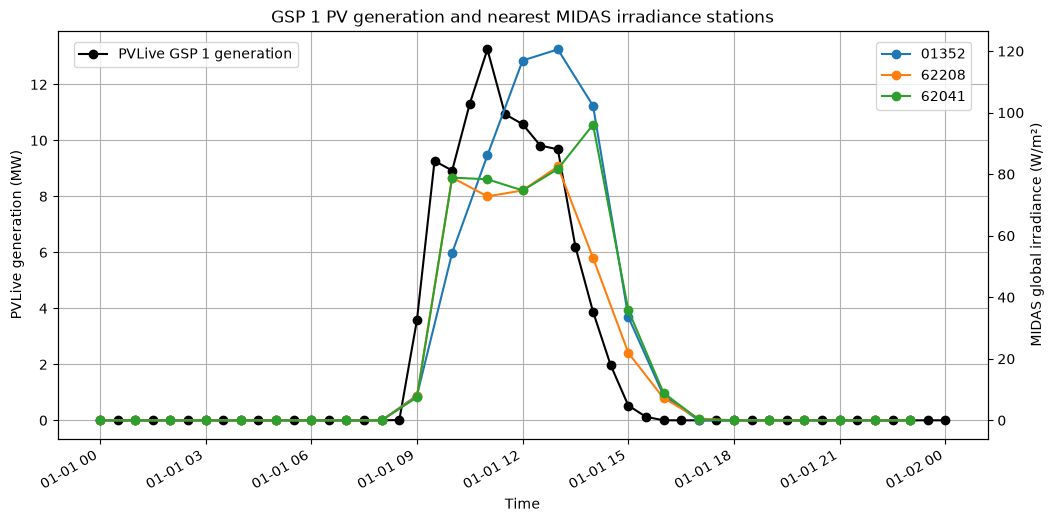

In [166]:
# Create the figure and the left-hand PVLive axis.
fig, ax_pv = plt.subplots(figsize=(12, 6))

# Plot PVLive generation on the left y-axis.
ax_pv.plot(
    hourly_data_gsp1["datetime_gmt"],
    hourly_data_gsp1["generation_mw"],
    color="black",
    marker="o",
    label="PVLive GSP 1 generation",
)

# Label the left-hand axis.
ax_pv.set_xlabel("Time")
ax_pv.set_ylabel("PVLive generation (MW)")
ax_pv.grid(True)

# Create a second y-axis sharing the same time axis.
ax_ghi = ax_pv.twinx()

# Find the converted MIDAS irradiance columns.
wm2_columns = [
    column
    for column in corrected_midas_hourly_wm2.columns
    if column.endswith("_wm2")
]

# Plot each MIDAS station on the right-hand y-axis.
for column in wm2_columns:
    ax_ghi.plot(
        corrected_midas_hourly_wm2["datetime_gmt"],
        corrected_midas_hourly_wm2[column],
        marker="o",
        label=column.replace("ghi_", "").replace("_wm2", ""),
    )

# Label the right-hand axis.
ax_ghi.set_ylabel("MIDAS global irradiance (W/m²)")

# Add a descriptive title.
ax_pv.set_title(
    "GSP 1 PV generation and nearest MIDAS irradiance stations"
)

# Put the two legends in separate corners so they do not overlap.
ax_pv.legend(
    loc="upper left",
    bbox_to_anchor=(0.01, 0.99),
)

ax_ghi.legend(
    loc="upper right",
    bbox_to_anchor=(0.99, 0.99),
)

# Give the timestamp labels enough room.
fig.autofmt_xdate()

# Display the finished plot.
plt.show()

### Step 4. Do a simple correl with this small sample (GSP 1 with three closest instruments)

- should eventually control for capacity, perhaps by dividing output by nominal capacity (given by PV_Live). though, i'm only considering one GSP so there's no difference
- i guess i should try doing a simple correl with the data I have available here first before looking at the broader dataset
- though I'll have to simplify the pv_live data to just hourly since i don't have half-hourly GHI

In [ ]:
# # make an hourly pvlive dataset
# pvlive_hourly = hourly_data_gsp1.copy()

# # use the timestamps as the df index
# pvlive_hourly = pvlive_hourly.set_index('datetime_gmt')

# # convert the half-hourly to hourly AVERAGES
# pvlive_hourly = pvlive_hourly[['generation_mw']].resample('1h').mean()

might be the wrong hourly average... should prob average the 9:30 and the 10:00 to get the 10:00!!!!!!!!!!!!
- so, ignore the above cell
- Corrected version:

In [191]:
hourly_data_gsp1.head(24)

,gsp_id,datetime_gmt,generation_mw
0,1,2024-01-02 00:00:00+00:00,0.000
1,1,2024-01-01 23:30:00+00:00,0.000
2,1,2024-01-01 23:00:00+00:00,0.000
3,1,2024-01-01 22:30:00+00:00,0.000
4,1,2024-01-01 22:00:00+00:00,0.000
5,1,2024-01-01 21:30:00+00:00,0.000
6,1,2024-01-01 21:00:00+00:00,0.000
7,1,2024-01-01 20:30:00+00:00,0.000
8,1,2024-01-01 20:00:00+00:00,0.000
9,1,2024-01-01 19:30:00+00:00,0.000


In [ ]:
# e.g. 12:30end is 9.817, 13:00end is 9.680
(9.817 + 9.680)/2 
# this mean should be the new averaged 13:00 time

9.7485

In [ ]:
# Make a copy so the original PVLive data remains unchanged.
pvlive_hourly = hourly_data_gsp1.copy()

# Use the period-ending timestamps as the index.
pvlive_hourly = pvlive_hourly.set_index(
    "datetime_gmt"
)

pvlive_hourly = (
    pvlive_hourly[
        ["generation_mw"]
    ]
    .resample(
        "1h",
        closed="right", #   include timestamps at the right-hand edge of each bin.
        label="right", #   label each hourly result with the time at which that period ended
    )
    .mean()
)

# Inspect the resulting timestamps and values.
pvlive_hourly.head(14)

,generation_mw
datetime_gmt,
2024-01-01 00:00:00+00:00,0.0000
2024-01-01 01:00:00+00:00,0.0000
2024-01-01 02:00:00+00:00,0.0000
2024-01-01 03:00:00+00:00,0.0000
2024-01-01 04:00:00+00:00,0.0000
2024-01-01 05:00:00+00:00,0.0000
2024-01-01 06:00:00+00:00,0.0000
2024-01-01 07:00:00+00:00,0.0000
2024-01-01 08:00:00+00:00,0.0000


^ nice, this does in fact agree.
- now let's move on to a simple correlation. I guess the simplest would be to average the three nearest GHI timeseries into one representative one.

In [208]:
pvlive_hourly.index

DatetimeIndex(['2024-01-01 00:00:00+00:00', '2024-01-01 01:00:00+00:00',
               '2024-01-01 02:00:00+00:00', '2024-01-01 03:00:00+00:00',
               '2024-01-01 04:00:00+00:00', '2024-01-01 05:00:00+00:00',
               '2024-01-01 06:00:00+00:00', '2024-01-01 07:00:00+00:00',
               '2024-01-01 08:00:00+00:00', '2024-01-01 09:00:00+00:00',
               '2024-01-01 10:00:00+00:00', '2024-01-01 11:00:00+00:00',
               '2024-01-01 12:00:00+00:00', '2024-01-01 13:00:00+00:00',
               '2024-01-01 14:00:00+00:00', '2024-01-01 15:00:00+00:00',
               '2024-01-01 16:00:00+00:00', '2024-01-01 17:00:00+00:00',
               '2024-01-01 18:00:00+00:00', '2024-01-01 19:00:00+00:00',
               '2024-01-01 20:00:00+00:00', '2024-01-01 21:00:00+00:00',
               '2024-01-01 22:00:00+00:00', '2024-01-01 23:00:00+00:00',
               '2024-01-02 00:00:00+00:00'],
              dtype='datetime64[us, UTC]', name='datetime_gmt', freq='h')

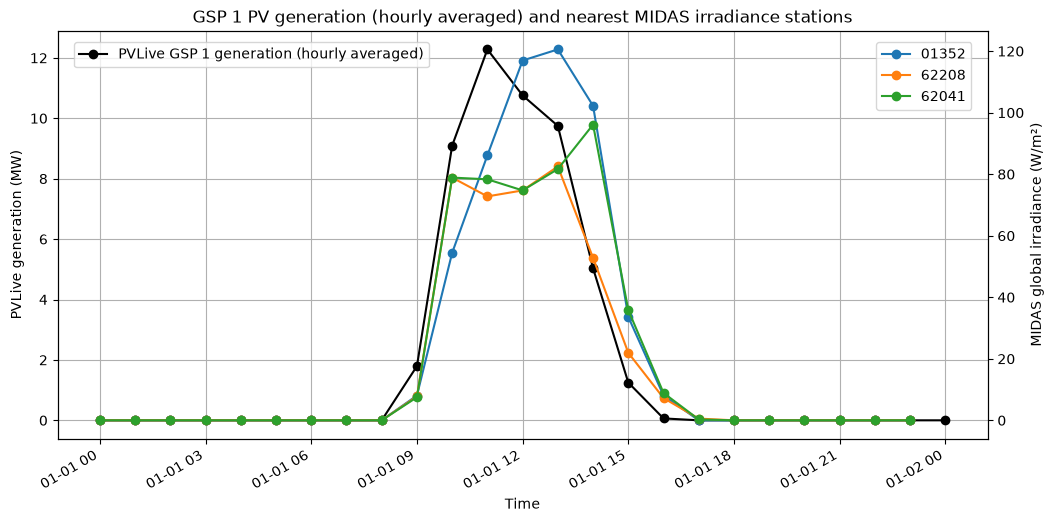

In [209]:
# redoing this plot but with the hourly averaged pv_live data; it smooths out much of the detail of the half-hourly curve unfortunately

# Create the figure and the left-hand PVLive axis.
fig, ax_pv = plt.subplots(figsize=(12, 6))

# Plot PVLive generation on the left y-axis.
ax_pv.plot(
    pvlive_hourly.index, # pvlive_hourly is weird now, need to use its index instead of column datetime_gmt
    pvlive_hourly["generation_mw"],
    color="black",
    marker="o",
    label="PVLive GSP 1 generation (hourly averaged)",
)

# Label the left-hand axis.
ax_pv.set_xlabel("Time")
ax_pv.set_ylabel("PVLive generation (MW)")
ax_pv.grid(True)

# Create a second y-axis sharing the same time axis.
ax_ghi = ax_pv.twinx()

# Find the converted MIDAS irradiance columns.
wm2_columns = [
    column
    for column in corrected_midas_hourly_wm2.columns
    if column.endswith("_wm2")
]

# Plot each MIDAS station on the right-hand y-axis.
for column in wm2_columns:
    ax_ghi.plot(
        corrected_midas_hourly_wm2["datetime_gmt"],
        corrected_midas_hourly_wm2[column],
        marker="o",
        label=column.replace("ghi_", "").replace("_wm2", ""),
    )

# Label the right-hand axis.
ax_ghi.set_ylabel("MIDAS global irradiance (W/m²)")

# Add a descriptive title.
ax_pv.set_title(
    "GSP 1 PV generation (hourly averaged) and nearest MIDAS irradiance stations"
)

# Put the two legends in separate corners so they do not overlap.
ax_pv.legend(
    loc="upper left",
    bbox_to_anchor=(0.01, 0.99),
)

ax_ghi.legend(
    loc="upper right",
    bbox_to_anchor=(0.99, 0.99),
)

# Give the timestamp labels enough room.
fig.autofmt_xdate()

# Display the finished plot.
plt.show()

-------------  Start of some codex-generated, copy-pasted code, because i'm getting a bit lazy today: -----------------

In [194]:
# Make a copy so the converted MIDAS data remains unchanged.
midas_for_correlation = (
    corrected_midas_hourly_wm2.copy()
)

# Use timestamps as the index.
midas_for_correlation = (
    midas_for_correlation.set_index("datetime_gmt")
)

# Select the converted irradiance columns.
wm2_columns = [
    column
    for column in midas_for_correlation.columns
    if column.endswith("_wm2")
]

# Calculate the average irradiance across the three stations.
midas_for_correlation["mean_ghi_wm2"] = (
    midas_for_correlation[wm2_columns]
    .mean(axis=1)
)

# Keep only the combined irradiance series.
midas_for_correlation = (
    midas_for_correlation[["mean_ghi_wm2"]]
)

# Join PVLive and MIDAS using timestamps that appear in both tables.
comparison_hourly = pvlive_hourly.join(
    midas_for_correlation,
    how="inner",
)

# Remove rows where either measurement is missing.
comparison_hourly = comparison_hourly.dropna(
    subset=[
        "generation_mw",
        "mean_ghi_wm2",
    ]
)

# Inspect the aligned data.
comparison_hourly

,generation_mw,mean_ghi_wm2
datetime_gmt,,
2024-01-01 00:00:00+00:00,0.0000,0.000000
2024-01-01 01:00:00+00:00,0.0000,0.000000
2024-01-01 02:00:00+00:00,0.0000,0.000000
2024-01-01 03:00:00+00:00,0.0000,0.000000
2024-01-01 04:00:00+00:00,0.0000,0.000000
2024-01-01 05:00:00+00:00,0.0000,0.000000
2024-01-01 06:00:00+00:00,0.0000,0.000000
2024-01-01 07:00:00+00:00,0.0000,0.000000
2024-01-01 08:00:00+00:00,0.0000,0.000000


In [195]:
# Calculate Pearson correlation between PV generation
# and average MIDAS irradiance.
correlation = comparison_hourly[
    "generation_mw"
].corr(
    comparison_hourly["mean_ghi_wm2"]
)

print(
    f"Pearson correlation: {correlation:.3f}"
)

Pearson correlation: 0.945


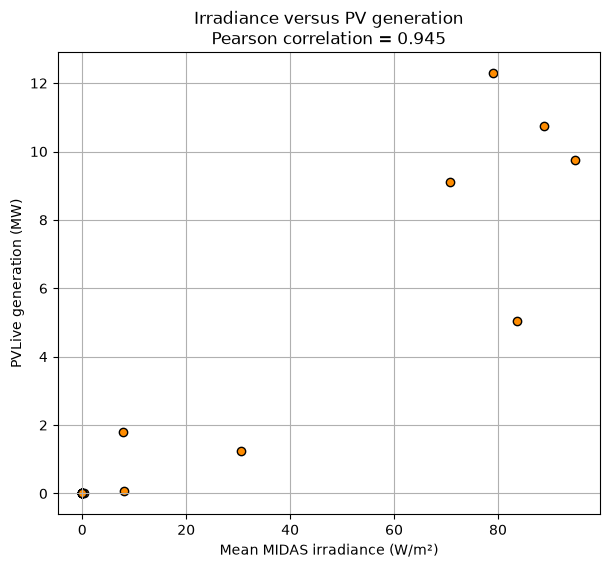

In [196]:
# Create a scatter plot of irradiance against PV generation.
fig, ax = plt.subplots(figsize=(7, 6))

ax.scatter(
    comparison_hourly["mean_ghi_wm2"],
    comparison_hourly["generation_mw"],
    color="darkorange",
    edgecolor="black",
)

# Label the axes.
ax.set_xlabel("Mean MIDAS irradiance (W/m²)")
ax.set_ylabel("PVLive generation (MW)")

# Add a title containing the correlation value.
ax.set_title(
    f"Irradiance versus PV generation\n"
    f"Pearson correlation = {correlation:.3f}"
)

# Add a grid to make the values easier to read.
ax.grid(True)

# Display the figure.
plt.show()

^ there simply aren't many (nonzero) points, so it makes sense that the correl would be high

But where are these instruments spatially compared to the GSP?

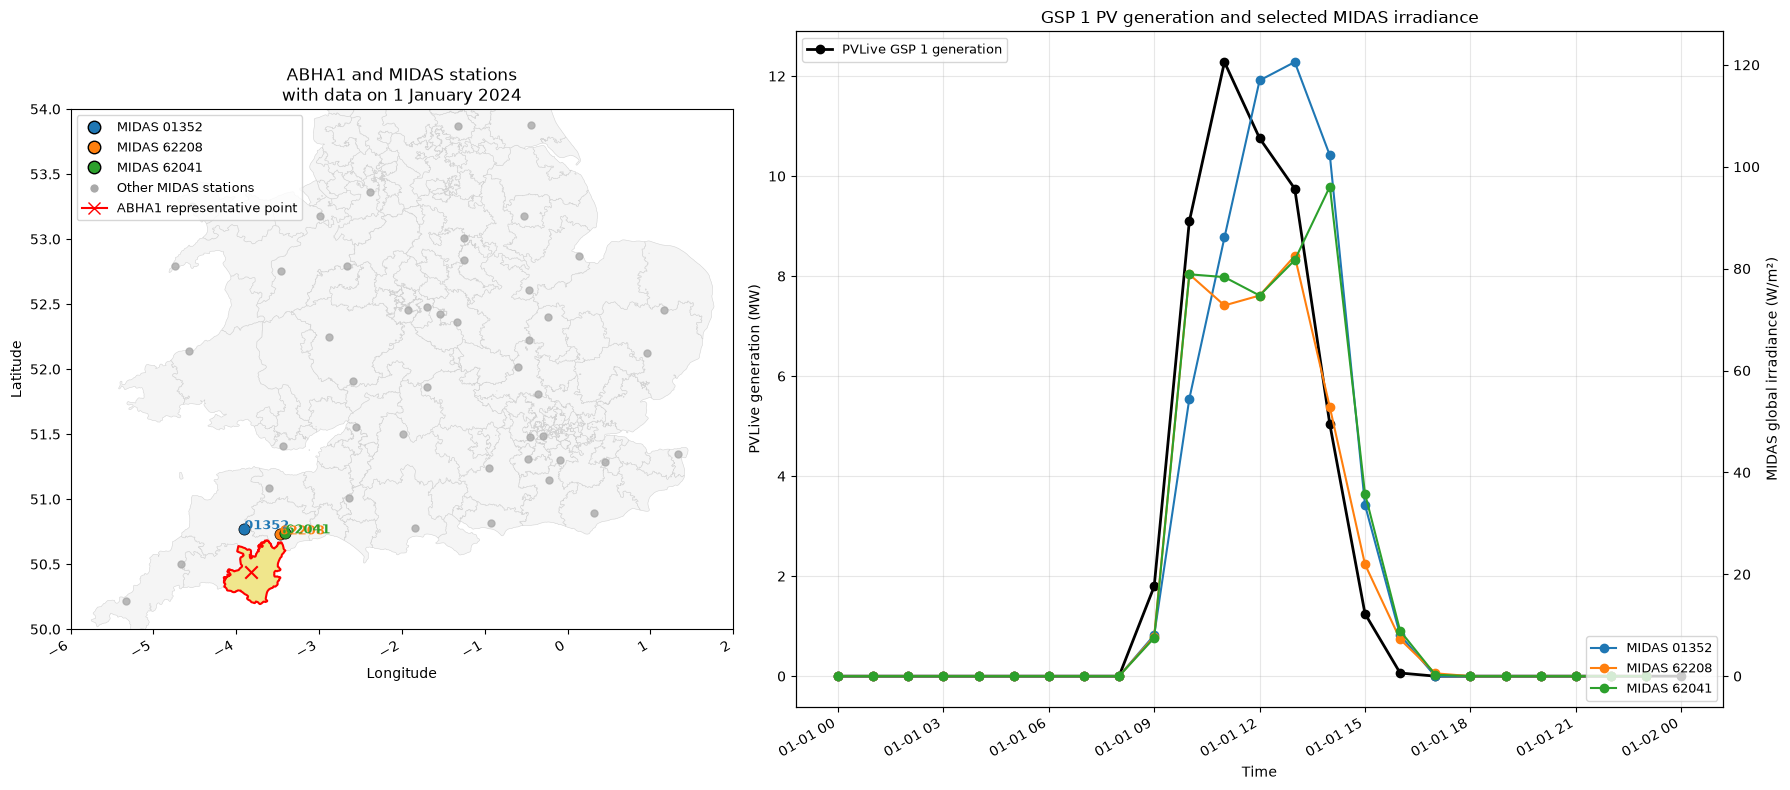

In [214]:
# Import Line2D so we can create a clean map legend manually.
from matplotlib.lines import Line2D

# Create a single figure with two panels:
# the map on the left and the time series on the right.
fig, (ax_map, ax_time) = plt.subplots(
    1,
    2,
    figsize=(18, 8),
    gridspec_kw={"width_ratios": [1, 1.4]},
)

# ---------------------------------------------------------------------
# Identify the selected MIDAS stations
# ---------------------------------------------------------------------

# Convert the selected station IDs to strings for consistent comparison.
selected_station_ids = [
    str(station_id)
    for station_id in closest_three["station_id"]
]

# Give each selected station a colour.
station_colours = {
    station_id: colour
    for station_id, colour in zip(
        selected_station_ids,
        ["tab:blue", "tab:orange", "tab:green"],
    )
}

# ---------------------------------------------------------------------
# Left panel: map
# ---------------------------------------------------------------------

# Plot all GSP regions as a light-grey background.
gsp_regions.plot(
    ax=ax_map,
    facecolor="whitesmoke",
    edgecolor="lightgrey",
    linewidth=0.4,
)

# Highlight ABHA1.
selected_region.plot(
    ax=ax_map,
    facecolor="khaki",
    edgecolor="red",
    linewidth=1.5,
)

# Plot every MIDAS station in dark grey first.
midas_points_jan1.plot(
    ax=ax_map,
    color="darkgrey",
    markersize=25,
    alpha=0.8,
    zorder=3,
)

# Plot the three selected stations again, using their time-series colours.
for station_id, colour in station_colours.items():
    selected_station = midas_points_jan1[
        midas_points_jan1["station_id"].astype(str)
        == station_id
    ]

    selected_station.plot(
        ax=ax_map,
        color=colour,
        edgecolor="black",
        linewidth=0.5,
        markersize=65,
        zorder=4,
    )

# Plot the representative point of the selected GSP.
selected_region.geometry.representative_point().plot(
    ax=ax_map,
    color="red",
    marker="x",
    markersize=80,
    zorder=5,
)

# Label the selected MIDAS stations on the map.
for station_id, colour in station_colours.items():
    selected_station = midas_points_jan1[
        midas_points_jan1["station_id"].astype(str)
        == station_id
    ]

    for _, station_row in selected_station.iterrows():
        ax_map.text(
            station_row.geometry.x,
            station_row.geometry.y,
            station_id,
            fontsize=9,
            color=colour,
            fontweight="bold",
            zorder=6,
        )

# Create map legend entries manually.
map_legend_handles = [
    Line2D(
        [0],
        [0],
        marker="o",
        color="w",
        markerfacecolor=colour,
        markeredgecolor="black",
        markersize=9,
        label=f"MIDAS {station_id}",
    )
    for station_id, colour in station_colours.items()
]

map_legend_handles.extend(
    [
        Line2D(
            [0],
            [0],
            marker="o",
            color="w",
            markerfacecolor="darkgrey",
            markersize=7,
            label="Other MIDAS stations",
        ),
        Line2D(
            [0],
            [0],
            marker="x",
            color="red",
            markersize=9,
            label="ABHA1 representative point",
        ),
    ]
)

ax_map.legend(
    handles=map_legend_handles,
    loc="upper left",
    fontsize=9,
)

ax_map.set_title(
    "ABHA1 and MIDAS stations\n"
    "with data on 1 January 2024"
)

ax_map.set_xlabel("Longitude")
ax_map.set_ylabel("Latitude")

# OPTIONAL: Zoom the map to the southern half of Great Britain.
ax_map.set_xlim(-6, 2)
ax_map.set_ylim(50, 54)

# ---------------------------------------------------------------------
# Right panel: time series
# ---------------------------------------------------------------------

# Plot PVLive generation on the left y-axis.
ax_pv = ax_time

ax_pv.plot(
    pvlive_hourly.index,
    pvlive_hourly["generation_mw"],
    color="black",
    marker="o",
    linewidth=2,
    label="PVLive GSP 1 generation",
)

ax_pv.set_xlabel("Time")
ax_pv.set_ylabel("PVLive generation (MW)")
ax_pv.grid(True, alpha=0.3)

# Create a second y-axis for MIDAS irradiance.
ax_ghi = ax_time.twinx()

# Plot each selected MIDAS station using the same colour
# used for its map point.
for station_id, colour in station_colours.items():
    column_name = f"ghi_{station_id}_wm2"

    # Only plot the column if it exists in the converted DataFrame.
    if column_name in corrected_midas_hourly_wm2.columns:
        ax_ghi.plot(
            corrected_midas_hourly_wm2["datetime_gmt"],
            corrected_midas_hourly_wm2[column_name],
            color=colour,
            marker="o",
            linewidth=1.5,
            label=f"MIDAS {station_id}",
        )

ax_ghi.set_ylabel("MIDAS global irradiance (W/m²)")

# Collect the two legends separately so they do not overlap.
pv_handles, pv_labels = ax_pv.get_legend_handles_labels()
ghi_handles, ghi_labels = ax_ghi.get_legend_handles_labels()

# Put the PVLive legend in the upper-left of the time-series panel.
ax_pv.legend(
    pv_handles,
    pv_labels,
    loc="upper left",
    fontsize=9,
)

# Put the MIDAS legend in the lower-right of the time-series panel.
ax_ghi.legend(
    ghi_handles,
    ghi_labels,
    loc="lower right",
    fontsize=9,
)

ax_time.set_title(
    "GSP 1 PV generation and selected MIDAS irradiance"
)

# Rotate date labels so they remain readable.
fig.autofmt_xdate()

# Add space between the map and time-series panels.
fig.tight_layout()


# Display the complete figure.
plt.show()